ANN_Tabular

Install & Import Libraries

In [ ]:
# Install libraries
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)
print("All libraries loaded ✅")

TensorFlow Version: 2.19.0
All libraries loaded ✅


# **Load Dataset from Kaggle**

In [ ]:
# Upload kaggle.json first OR use this direct method
# Dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

from google.colab import files

# Option 1: Upload CSV manually
uploaded = files.upload()  # Upload heart.csv from your PC

import io
df = pd.read_csv(io.BytesIO(uploaded['heart.csv']))

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Saving heart.csv to heart.csv
Dataset Shape: (918, 12)

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# **Data Exploration**

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

=== Missing Values ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR       

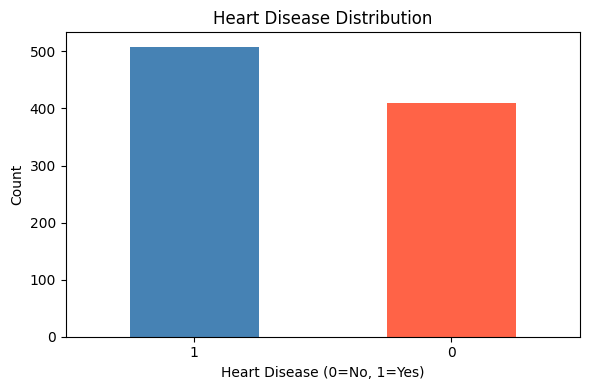

In [ ]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Distribution ===")
print(df['HeartDisease'].value_counts())

# Visualize target distribution
plt.figure(figsize=(6,4))
df['HeartDisease'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

# **Data Preprocessing**

In [ ]:
# Encode categorical columns
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])

# Separate features and target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Features shape: (918, 20)
Target shape: (918,)

Feature columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']

Training samples: 734
Testing samples : 184


# **Build ANN Model**

In [ ]:
# Build ANN
model = Sequential([
    # Input Layer
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 1
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 384 (1.50 KB)

# **Train the Model**

In [ ]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Model Training Complete!")

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6457 - loss: 0.6808 - val_accuracy: 0.8027 - val_loss: 0.5797
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7990 - loss: 0.4483 - val_accuracy: 0.8163 - val_loss: 0.5094
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8416 - loss: 0.3919 - val_accuracy: 0.8231 - val_loss: 0.4773
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8603 - loss: 0.3655 - val_accuracy: 0.8299 - val_loss: 0.4585
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8416 - loss: 0.3850 - val_accuracy: 0.8367 - val_loss: 0.4438
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8722 - loss: 0.3343 - val_accuracy: 0.8367 - val_loss: 0.4417
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8569 - loss: 0.3446 - val_accuracy: 0.8367 - val_loss: 0.4395
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8807 - loss: 0.3102 - val_accuracy: 0.8231 - 

# **Accuracy & Loss Graphs**

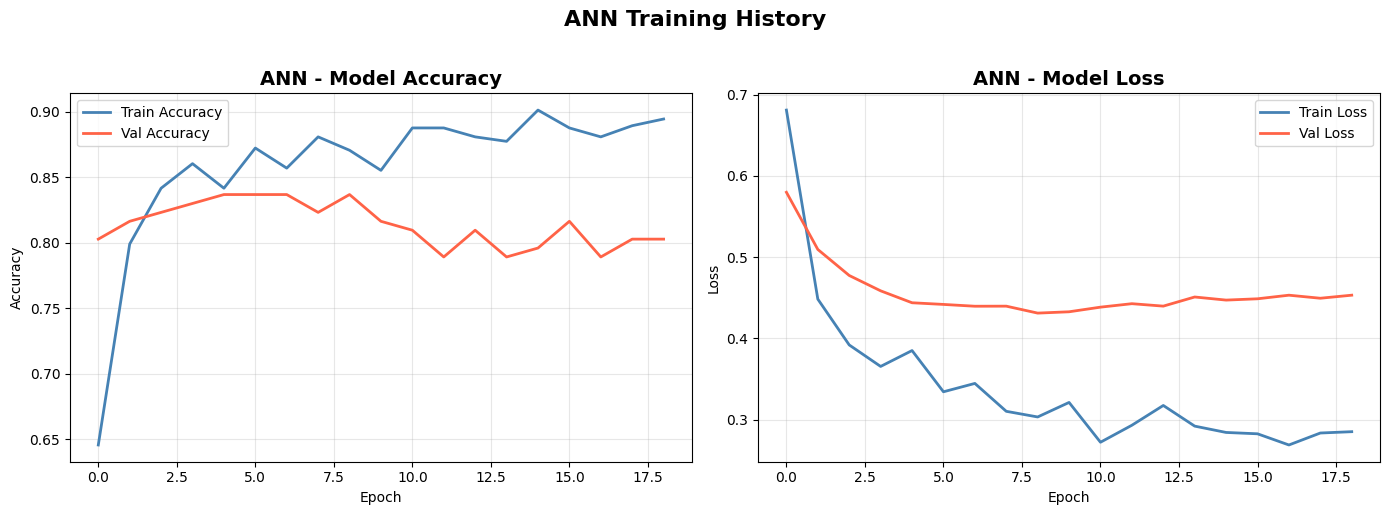

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy Graph ---
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato',    linewidth=2)
axes[0].set_title('ANN - Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Loss Graph ---
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato',    linewidth=2)
axes[1].set_title('ANN - Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ANN Training History', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ann_accuracy_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# **Evaluate Model**

In [ ]:
# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ ANN Test Accuracy: {acc*100:.2f}%")

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
✅ ANN Test Accuracy: 87.50%

=== Classification Report ===
               precision    recall  f1-score   support

   No Disease       0.93      0.78      0.85        82
Heart Disease       0.84      0.95      0.89       102

     accuracy                           0.88       184
    macro avg       0.89      0.87      0.87       184
 weighted avg       0.88      0.88      0.87       184



# **Confusion Matrix**

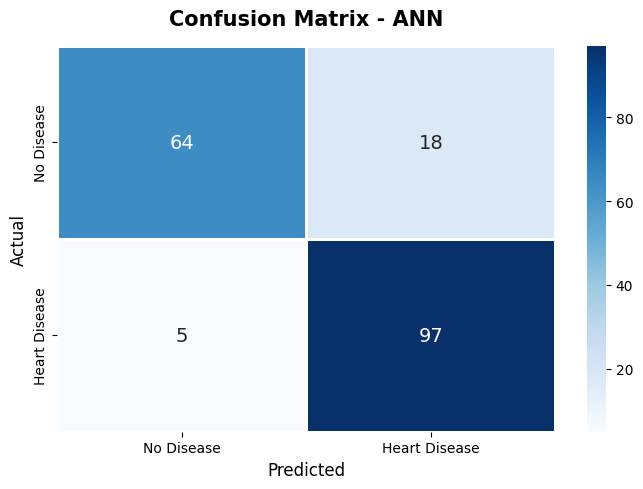


True Positive  (TP): 97
True Negative  (TN): 64
False Positive (FP): 18
False Negative (FN): 5


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'],
            linewidths=1, linecolor='white', annot_kws={"size": 14})

plt.title('Confusion Matrix - ANN', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('ann_confusion_matrix.png', dpi=150)
plt.show()

# Print values
TP = cm[1][1]; TN = cm[0][0]
FP = cm[0][1]; FN = cm[1][0]
print(f"\nTrue Positive  (TP): {TP}")
print(f"True Negative  (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")

# **Save Model**

In [ ]:
# Save trained model
model.save('ann_heart_disease_model.h5')
print("✅ Model saved as ann_heart_disease_model.h5")

# Download all graphs
from google.colab import files
files.download('ann_accuracy_loss.png')
files.download('ann_confusion_matrix.png')
files.download('ann_heart_disease_model.h5')

✅ Model saved as ann_heart_disease_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>